In [4]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
df = pd.read_csv("ecommerce_sales_data.csv")

In [5]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [13]:
df.tail()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28
3499,2024-11-01,Smartwatch,Electronics,East,9,10530,1777.32


In [26]:
df.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='str')

In [12]:
df.shape

(3500, 7)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3500 non-null   datetime64[us]
 1   Product Name  3500 non-null   str           
 2   Category      3500 non-null   str           
 3   Region        3500 non-null   str           
 4   Quantity      3500 non-null   int64         
 5   Sales         3500 non-null   int64         
 6   Profit        3500 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 191.5 KB


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3500 non-null   datetime64[us]
 1   Product Name  3500 non-null   str           
 2   Category      3500 non-null   str           
 3   Region        3500 non-null   str           
 4   Quantity      3500 non-null   int64         
 5   Sales         3500 non-null   int64         
 6   Profit        3500 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 191.5 KB


In [9]:
df.describe()

,Order Date,Quantity,Sales,Profit
count,3500,3500.000000,3500.000000,3500.000000
mean,2023-07-13 00:53:53.828571,4.931714,3047.966000,527.047203
min,2022-01-01 00:00:00,1.000000,51.000000,6.970000
25%,2022-10-16 18:00:00,3.000000,1049.500000,158.695000
50%,2023-07-21 12:00:00,5.000000,2350.500000,361.070000
75%,2024-04-16 06:00:00,7.000000,4537.000000,729.125000
max,2024-12-31 00:00:00,9.000000,10782.000000,2946.930000
std,NaN,2.575895,2440.213237,504.139732


In [8]:
df.dtypes

Order Date      datetime64[us]
Product Name               str
Category                   str
Region                     str
Quantity                 int64
Sales                    int64
Profit                 float64
dtype: object

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 10667881


In [16]:
total_profit = df["Profit"].sum()
print("Total Profit:", total_profit)

Total Profit: 1844665.21


In [17]:
total_orders = len(df)
print("Total Orders:", total_orders)

Total Orders: 3500


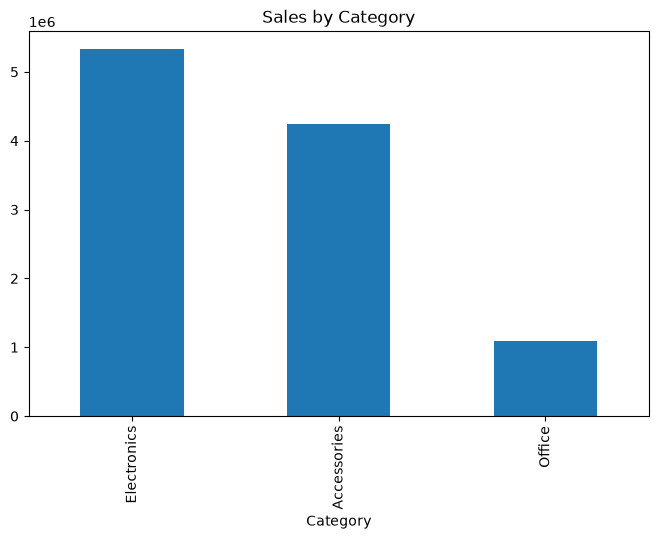

In [18]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Sales by Category"
)

plt.show()

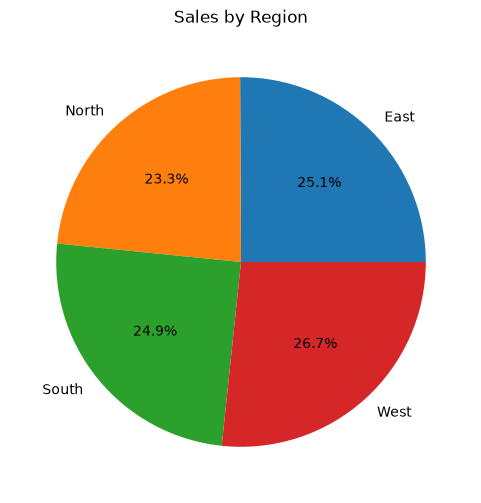

In [19]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Sales by Region")
plt.ylabel("")
plt.show()

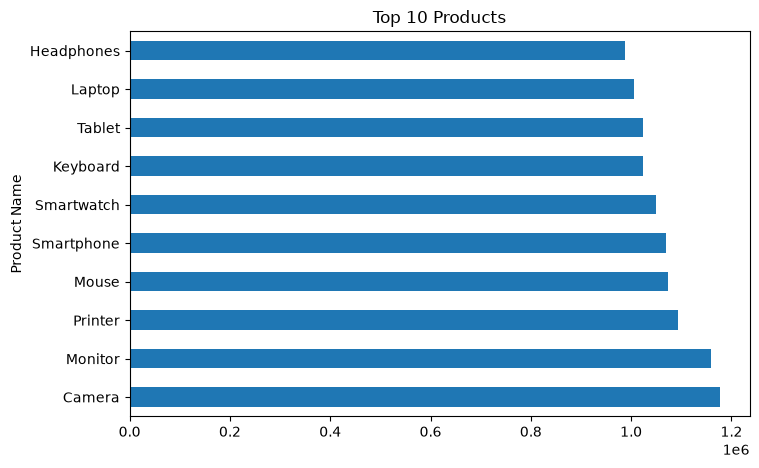

In [20]:
top_products = df.groupby("Product Name")["Sales"].sum().nlargest(10)

top_products.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Products")
plt.show()

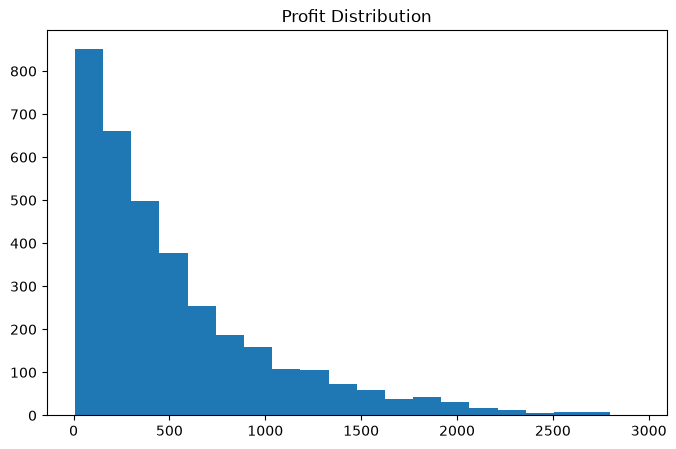

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df["Profit"], bins=20)
plt.title("Profit Distribution")
plt.show()

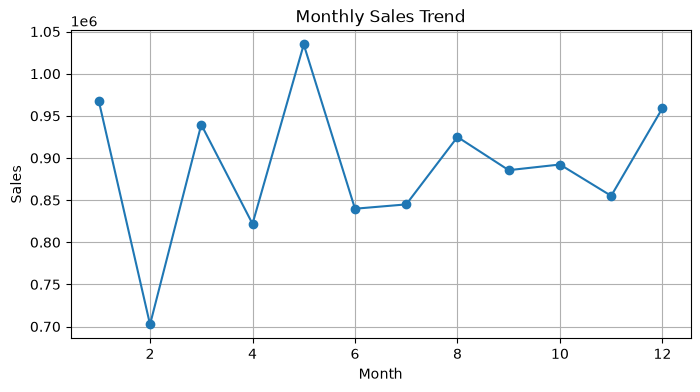

In [22]:
monthly_sales = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

plt.figure(figsize=(8,4))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

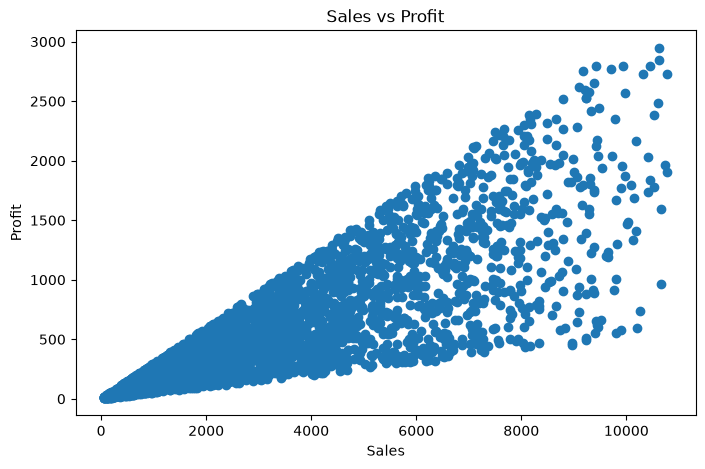

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

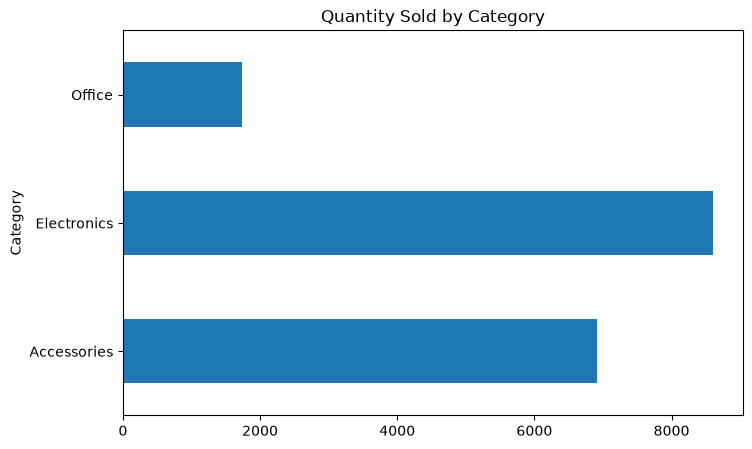

In [27]:
qty_category = df.groupby('Category')['Quantity'].sum()

plt.figure(figsize=(8,5))
qty_category.plot(kind='barh')
plt.title('Quantity Sold by Category')
plt.show()

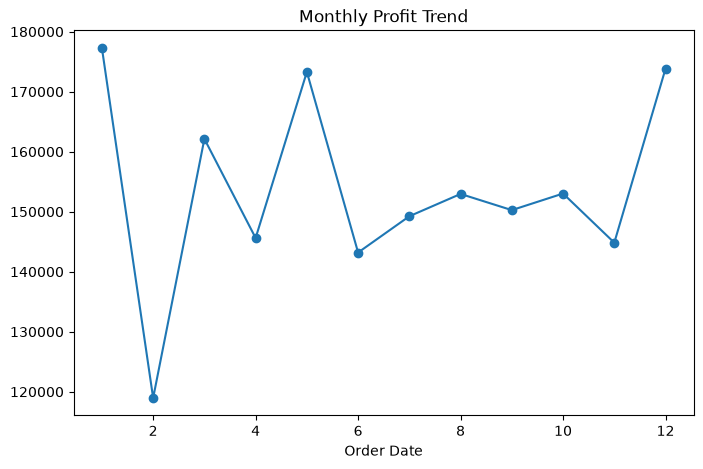

In [28]:
monthly_profit = df.groupby(df['Order Date'].dt.month)['Profit'].sum()

plt.figure(figsize=(8,5))
monthly_profit.plot(kind='line', marker='o')
plt.title('Monthly Profit Trend')
plt.show()